Captura do DF

In [10]:
import os
import pymysql
import pandas as pd
from dotenv import load_dotenv

pd.set_option('display.float_format', '{:.2f}'.format)

query = "select * from IMDB_movies"

load_dotenv()

host = os.getenv("DB_IP")
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
schema = os.getenv("DB_SCHEMA")
database = os.getenv("DB_NAME")
port = int(os.getenv("DB_PORT"))


conn = pymysql.connect(
    host=host,
    user=user,
    password=password,
    database=database,
    port=port
)

df = pd.read_sql(query, conn)

print(df)

conn.close()

       Id                    Title                     Genre  \
0       1  Guardians of the Galaxy   Action,Adventure,Sci-Fi   
1       2               Prometheus  Adventure,Mystery,Sci-Fi   
2       3                    Split           Horror,Thriller   
3       4                     Sing   Animation,Comedy,Family   
4       5            Suicide Squad  Action,Adventure,Fantasy   
..    ...                      ...                       ...   
995   996     Secret in Their Eyes       Crime,Drama,Mystery   
996   997          Hostel: Part II                    Horror   
997   998   Step Up 2: The Streets       Drama,Music,Romance   
998   999             Search Party          Adventure,Comedy   
999  1000               Nine Lives     Comedy,Family,Fantasy   

                 Director                                             Actors  \
0              James Gunn  Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...   
1            Ridley Scott  Noomi Rapace, Logan Marshall-Green, Michael 

C:\Users\larys\AppData\Local\Temp\ipykernel_15024\2679161418.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


<h1>Pergunta 01: Quantos gêneros de filmes foram feitos por ano</h1>

   Year      Genre  qtd_filmes
0  2006     Action          11
1  2006  Adventure          13
2  2006  Animation           2
3  2006  Biography           3
4  2006     Comedy          12


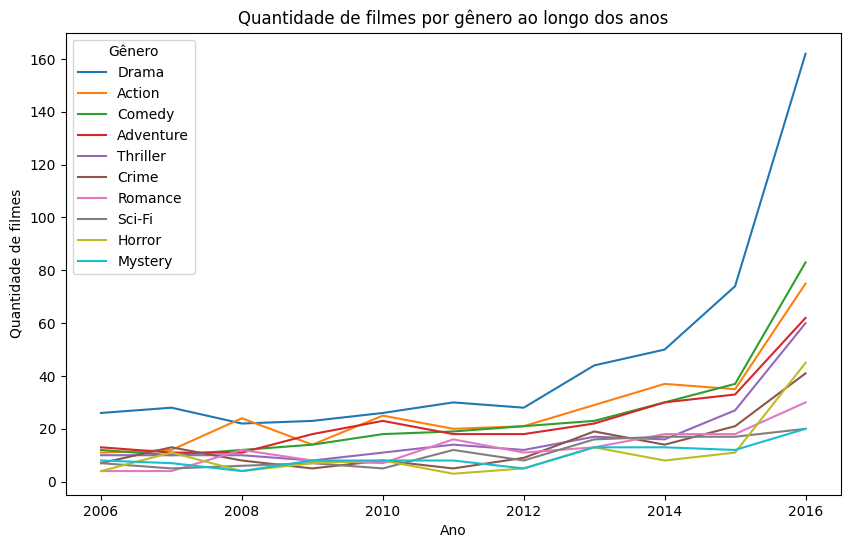

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_1 = df[["Year", "Genre"]].copy()

# separar generos
df_1["Genre"] = df_1["Genre"].str.split(",")

# transformar cada genero em uma linha
df_1 = df_1.explode("Genre")

# remover espaços extras
df_1["Genre"] = df_1["Genre"].str.strip()

# contar filmes por ano e genero
df_count = (
    df_1.groupby(["Year", "Genre"])
      .size()
      .reset_index(name="qtd_filmes")
)

print(df_count.head())

# pivot para facilitar o gráfico
df_pivot = df_count.pivot(
    index="Year",
    columns="Genre",
    values="qtd_filmes"
).fillna(0)

# plot
df_pivot.plot(figsize=(10,6))

plt.title("Quantidade de filmes por gênero ao longo dos anos")
plt.xlabel("Ano")
plt.ylabel("Quantidade de filmes")
plt.legend(title="Gênero")
plt.show()